In [1]:
# Importing standard libs, data tools, and plotting utilities
import time
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.collections import LineCollection
import matplotlib.ticker as mticker
import warnings

In [ ]:
# Loading the raw observation results and pre-aggregated route performance data
result = pd.read_csv('metrics_results/mar1_analysis.csv', low_memory=False)
perf = pd.read_csv('metrics_results/performance_results.csv')

In [3]:
# Filtering to valid observations — matched trips only, no pre-trip or ghost signals, delay present
# Mirrors the filter used inside analyze_route_performance
clean = result[
    result['match_type'].isin(['stst', 'fallback_pid', 'fallback_route']) &
    ~result['pre_trip'].fillna(False) &
    ~result['is_ghost'].fillna(False) &
    result['delay_minutes'].notna()
].copy()

In [ ]:
warnings.filterwarnings('ignore')

# Setting up the dark theme for all plots
plt.rcParams.update({
    'font.family':        'monospace',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.spines.left':   False,
    'axes.spines.bottom': False,
    'axes.grid':          True,
    'grid.color':         '#2a2a3a',
    'grid.linewidth':     0.5,
    'axes.facecolor':     '#0f0f1a',
    'figure.facecolor':   '#0f0f1a',
    'text.color':         '#ffffff',
    'axes.labelcolor':    '#e0e0f0',
    'xtick.color':        '#FFFFFF',
    'ytick.color':        '#FFFFFF',
    'axes.titlecolor':    '#ffffff',
    'axes.titlesize':     13,
    'axes.labelsize':     10,
})

# Color palette — used consistently across all figures
BG     = '#0f0f1a'
PANEL  = '#16162a'
GREEN  = '#03ffb3'
YELLOW = '#ffbb00'
ORANGE = '#ff5100'
RED    = '#ff0033'
BLUE   = '#005eff'
GREY   = '#555577'
WHITE  = '#e0e0f0'

# Orderings for time-of-day and day-of-week labels
TOD_ORDER = ['Early Morning', 'AM Peak', 'Midday', 'PM Peak', 'Evening']
DOW_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

def otp_color(v):
    """This function takes an OTP percentage, maps it to a severity tier, and returns the corresponding hex color."""
    if v >= 85: return GREEN
    if v >= 75: return YELLOW
    if v >= 65: return ORANGE
    return RED

def delay_color(d):
    """This function takes a delay value in minutes, classifies it by severity, and returns the corresponding hex color."""
    if d < -1:  return GREEN
    if d <= 3:  return YELLOW
    if d <= 8:  return ORANGE
    return RED

print('\u2713 Setup complete')

✓ Setup complete


In [ ]:
# =============================================================================
# TRIP-LEVEL VIEW
# Metrics come from performance_results.csv which is already trip-aggregated.
# This just gives us a trip-level dataframe for hourly / TOD charts.
# =============================================================================

def get_tod(h):
    """This function takes a scheduled departure hour, bins it into a named time-of-day period, and returns the label string."""
    if h < 6:   return 'Early Morning'
    if h < 10:  return 'AM Peak'
    if h < 15:  return 'Midday'
    if h < 19:  return 'PM Peak'
    return 'Evening'

# Parsing timestamps and deriving temporal features
clean['tmstmp_dt'] = pd.to_datetime(clean['tmstmp'])
clean['hour'] = clean['tmstmp_dt'].dt.hour
clean['dow'] = clean['tmstmp_dt'].dt.day_name()
clean['is_weekend'] = clean['tmstmp_dt'].dt.dayofweek >= 5
clean['date'] = clean['tmstmp_dt'].dt.date
clean['sched_dep_hour'] = (clean['scheduled_departure_stop1'] // 60).astype('Int64')
clean['tod'] = clean['sched_dep_hour'].apply(
    lambda h: get_tod(h) if pd.notna(h) else get_tod(0)
)

# Collapsing observations to one row per trip with delay stats
trips = (
    clean.groupby(
        ['matched_trip_id', 'route_id', 'trip_date', 'date',
         'tod', 'dow', 'is_weekend'],
        observed=True
    )
    .agg(
        delay_median  = ('delay_minutes', 'median'),
        delay_max = ('delay_minutes', 'max'),
        delay_p90 = ('delay_minutes', lambda x: x.quantile(0.9)),
        delay_std = ('delay_minutes', 'std'),
        n_obs = ('delay_minutes', 'count'),
        sched_dep_min = ('scheduled_departure_stop1', 'first'),
    )
    .reset_index()
)

# Flagging each trip by punctuality category
trips['is_late'] = trips['delay_median'] > 3
trips['is_very_late'] = trips['delay_median'] > 15
trips['is_early'] = trips['delay_median'] < -1
trips['is_ontime'] = ~trips['is_early'] & ~trips['is_late']
trips['hour'] = (trips['sched_dep_min'] // 60).astype('Int64')

print(f'Trips: {len(trips):,} | Routes: {trips["route_id"].nunique()} | Dates: {trips["date"].nunique()}')

Trips: 224,251 | Routes: 123 | Dates: 15


In [ ]:
# =============================================================================
# BUS TRUST SCORE — built from performance_results.csv
# All four pillars are computed here from trip-level perf columns.
# =============================================================================

df = perf.copy()
df['route_id'] = df['route_id'].astype(str)

# Computing the four trust pillars — each normalized to 0-100
df['p_otp'] = df['overall_otp_pct'].clip(0, 100)
df['p_severity'] = (1 - (df['overall_delay_median'].clip(0, 15) / 15)) * 100
df['p_reliability'] = (1 - (df['overall_delay_std'].clip(0, 12) / 12)) * 100
df['p_ghost'] = (1 - (df['ghost_rate_pct'].clip(0, 40) / 40)) * 100

# Weighted composite: OTP dominates (45%), ghost is a minor penalty (10%)
df['bus_trust_score'] = (
    0.45 * df['p_otp'] +
    0.25 * df['p_severity'] +
    0.20 * df['p_reliability'] +
    0.10 * df['p_ghost']
).round(1)

def trust_tier(s):
    """This function takes a bus trust score, maps it to a named reliability tier, and returns the tier label string."""
    if s >= 80: return 'HIGH'
    if s >= 65: return 'MODERATE'
    if s >= 50: return 'LOW'
    return 'CRITICAL'

df['trust_tier'] = df['bus_trust_score'].apply(trust_tier)
df_sorted = df.sort_values('bus_trust_score', ascending=False).reset_index(drop=True)
df_sorted['rank'] = df_sorted.index + 1

# Identifying the four worst-performing routes for downstream figures
WORST4 = df_sorted.tail(4)['route_id'].tolist()[::-1]
print('Worst 4 routes:', WORST4)
print(df_sorted.tail(4)[['route_id', 'bus_trust_score', 'trust_tier',
                           'overall_otp_pct', 'overall_delay_std', 'ghost_rate_pct']])

Worst 4 routes: ['169', '62', '171', 'N5']
    route_id  bus_trust_score trust_tier  overall_otp_pct  overall_delay_std  \
119       N5             61.7        LOW            77.31              10.36   
120      171             57.7        LOW            61.66              11.03   
121       62             56.4        LOW            50.64               6.26   
122      169             54.2        LOW            44.05               5.70   

     ghost_rate_pct  
119           64.48  
120           16.55  
121           23.96  
122           17.65  


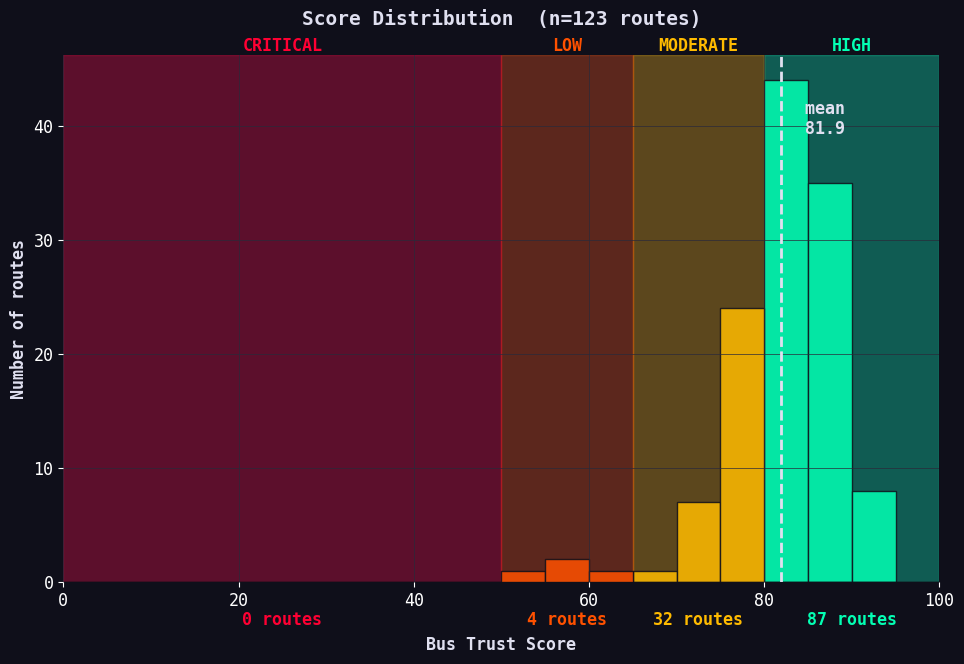

✓ Figure 1 saved


In [ ]:
# Plotting the Bus Trust Score distribution across all routes

fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)

scores = df_sorted['bus_trust_score']
tier_bands = [(80,100,GREEN,'HIGH'),(65,80,YELLOW,'MODERATE'), (50,65,ORANGE,'LOW'),(0,50,RED,'CRITICAL')]

# Shading tier regions and labeling them at the top
for lo, hi, col, label in tier_bands:
    ax.axvspan(lo, hi, color=col, alpha=0.3)
    ax.text((lo+hi)/2, 1, label, transform=ax.get_xaxis_transform(),
            ha='center', va='bottom', fontsize=12, color=col, fontweight='bold')

# Drawing each tier's histogram segment in its own color
bins = np.arange(0, 105, 5)
for lo, hi, col, _ in tier_bands:
    mask = (scores >= lo) & (scores < hi)
    if mask.any():
        ax.hist(scores[mask], bins=bins, color=col, alpha=0.85, edgecolor=BG, linewidth=1)

# Mean reference line
ax.axvline(scores.mean(), color=WHITE, lw=2, ls='--')
ax.text(scores.mean()+0.5, ax.get_ylim()[1]*0.85,
        f'  mean\n  {scores.mean():.1f}', color=WHITE, fontsize=12, fontweight='bold')

ax.set_xlabel('\nBus Trust Score', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of routes', fontsize=12, fontweight='bold')
ax.set_title('Score Distribution  (n=123 routes)\n', color=WHITE, fontsize=14, fontweight='bold')
ax.set_xlim(0, 100)
ax.set_facecolor(PANEL)
ax.tick_params(axis='both', labelsize=12)

# Annotating route counts per tier below the x-axis
for lo, hi, col, _ in tier_bands:
    n = ((scores >= lo) & (scores < hi)).sum()
    ax.text((lo+hi)/2, -0.08, f'{n} routes', ha='center', fontsize=12,
            color=col, fontweight='bold', transform=ax.get_xaxis_transform())

plt.tight_layout(pad=2)
plt.savefig('pres_1_trust_distribution.png', dpi=1000, bbox_inches='tight', facecolor=BG)
plt.show()
print('\u2713 Figure 1 saved')

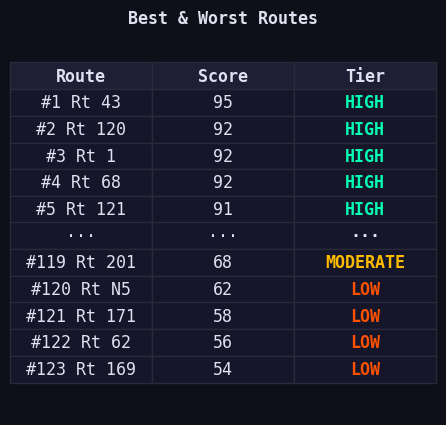

✓ Figure 2 saved


In [8]:
# Plotting the Best & Worst Routes summary table (top 5 / bottom 5)

fig, ax = plt.subplots(figsize=(5, 5), facecolor=BG)
ax.set_facecolor(PANEL)
ax.axis('off')

# Building table rows — top 5, separator, bottom 5
table_data = []
for _, row in df_sorted.head(5).iterrows():
    table_data.append([f"#{row['rank']} Rt {row['route_id']}",
                       f"{row['bus_trust_score']:.0f}", row['trust_tier']])
table_data.append(['\u00b7\u00b7\u00b7', '\u00b7\u00b7\u00b7', '\u00b7\u00b7\u00b7'])
for _, row in df_sorted.tail(5).iterrows():
    table_data.append([f"#{row['rank']} Rt {row['route_id']}",
                       f"{row['bus_trust_score']:.0f}", row['trust_tier']])

tbl = ax.table(cellText=table_data, colLabels=['Route','Score','Tier'],
               loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(12)
tbl.scale(1.1, 1.6)

# Coloring tier cells and styling headers
tier_color_map = {'HIGH': GREEN, 'MODERATE': YELLOW, 'LOW': ORANGE, 'CRITICAL': RED}
for (row_i, col_i), cell in tbl.get_celld().items():
    cell.set_facecolor(PANEL)
    cell.set_edgecolor('#2a2a3a')
    cell.set_text_props(color=WHITE)
    if row_i == 0:
        cell.set_facecolor('#1e1e35')
        cell.set_text_props(color=WHITE, fontweight='bold', fontsize=12)
    if col_i == 2 and row_i > 0:
        tier_val = table_data[row_i - 1][2]
        cell.set_text_props(color=tier_color_map.get(tier_val, WHITE), fontweight='bold')

ax.set_title('Best & Worst Routes', color=WHITE, fontsize=12, pad=5, fontweight='bold')
plt.savefig('pres_2_best&worst_routes.png', dpi=1000, bbox_inches='tight', facecolor=BG)
plt.show()
print('\u2713 Figure 2 saved')

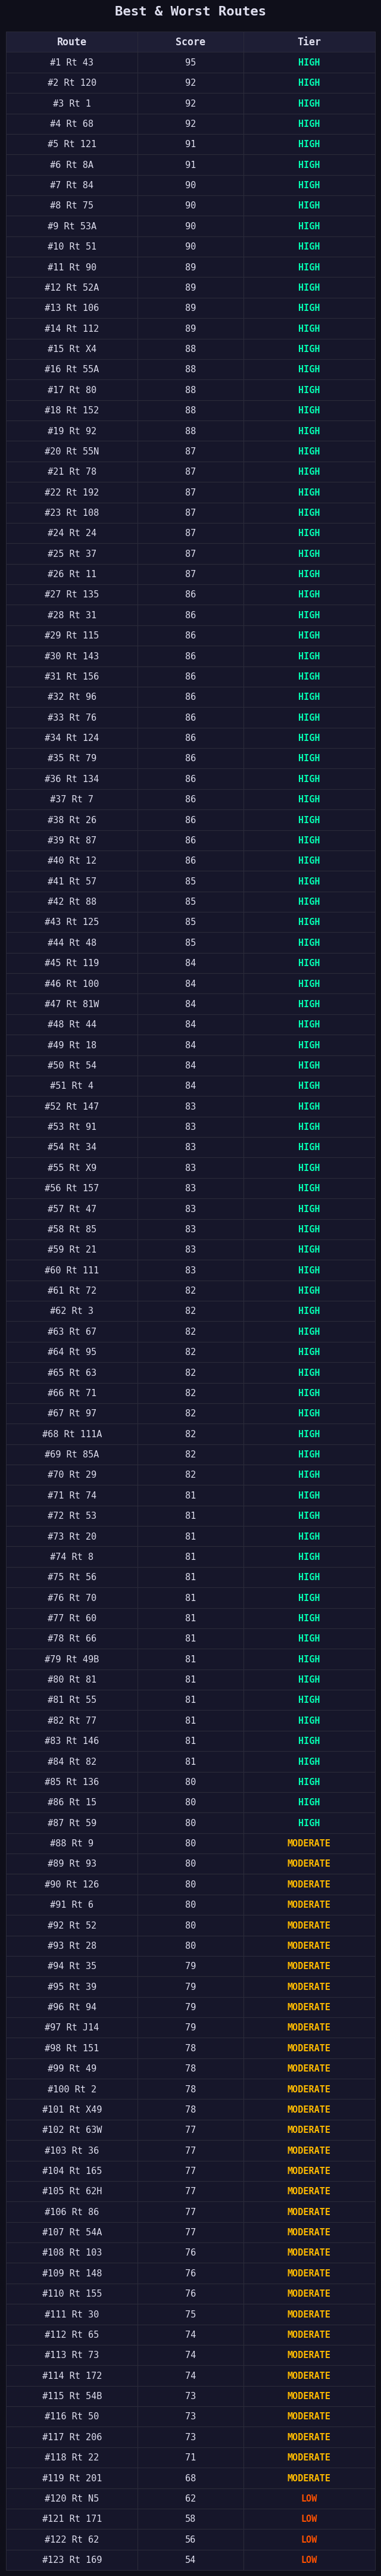

✓ Figure 2a saved


In [38]:
# Plotting the full ranked route table — all routes, scored and tiered

n_rows = len(df_sorted)

# Dynamically scaling figure height to number of routes
fig_height = max(6, n_rows * 0.45)

fig, ax = plt.subplots(figsize=(8, fig_height), facecolor=BG)

ax.set_title(
    'Best & Worst Routes',
    color=WHITE,
    fontsize=16,
    fontweight='bold',
    pad=2
)

ax.set_facecolor(PANEL)
ax.axis('off')

# Building table data from the sorted route list
table_data = []
for _, row in df_sorted.iterrows():
    table_data.append([
        f"#{row['rank']} Rt {row['route_id']}",
        f"{row['bus_trust_score']:.0f}",
        row['trust_tier']
    ])

tbl = ax.table(
    cellText=table_data,
    colLabels=['Route', 'Score', 'Tier'],
    cellLoc='center',
    colWidths=[0.25, 0.2, 0.25],
    bbox=[0, 0, 1, 1]
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(11)

tier_color_map = {
    'HIGH': GREEN,
    'MODERATE': YELLOW,
    'LOW': ORANGE,
    'CRITICAL': RED
}

# Styling cells — coloring tier text and bolding the header row
for (row_i, col_i), cell in tbl.get_celld().items():

    cell.set_facecolor(PANEL)
    cell.set_edgecolor('#2a2a3a')
    cell.set_linewidth(0.8)
    cell.set_text_props(color=WHITE)

    # Header
    if row_i == 0:
        cell.set_facecolor('#1e1e35')
        cell.set_text_props(color=WHITE, fontweight='bold', fontsize=12)

    # Tier color
    if col_i == 2 and row_i > 0:
        tier_val = table_data[row_i - 1][2]
        cell.set_text_props(
            color=tier_color_map.get(tier_val, WHITE),
            fontweight='bold'
        )

plt.savefig(
    'pres_2a_best&worst_routes.png',
    dpi=1000,
    bbox_inches='tight',
    facecolor=BG
)

plt.show()
print('\u2713 Figure 2a saved')

In [45]:
# Loading the static GTFS schedule data from parquet for map building
import pyarrow.parquet as pq

static_data = pq.read_table('gtfs_cache/static_data.parquet').to_pandas()
print(static_data.shape)
print(static_data.columns.tolist())
print(static_data.head(3))

(2996069, 14)
['route_id', 'trip_id', 'shape_id', 'stop_sequence', 'arrival_minutes', 'departure_minutes', 'shape_dist_traveled', 'stop_id', 'stop_name', 'stop_lat', 'stop_lon', 'service_id', 'direction', 'schd_trip_id']
  route_id        trip_id  shape_id  stop_sequence  arrival_minutes  \
0        1  6770004362020  67706351              1           980.50   
1        1  6770004362020  67706351              2           981.30   
2        1  6770004362020  67706351              3           982.15   

   departure_minutes  shape_dist_traveled stop_id  \
0             980.50                    0   13155   
1             981.30                  689   18661   
2             982.15                 1527   18498   

                        stop_name   stop_lat   stop_lon service_id direction  \
0  Desplaines & Harrison Terminal  41.874451 -87.644351      67701     South   
1            Jefferson & Harrison  41.874611 -87.642345      67701     South   
2           Jefferson & Van Buren  41.876

In [47]:
pip install geopandas contextily

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [contextily]
Note: you may need to restart the kernel to use updated packages.


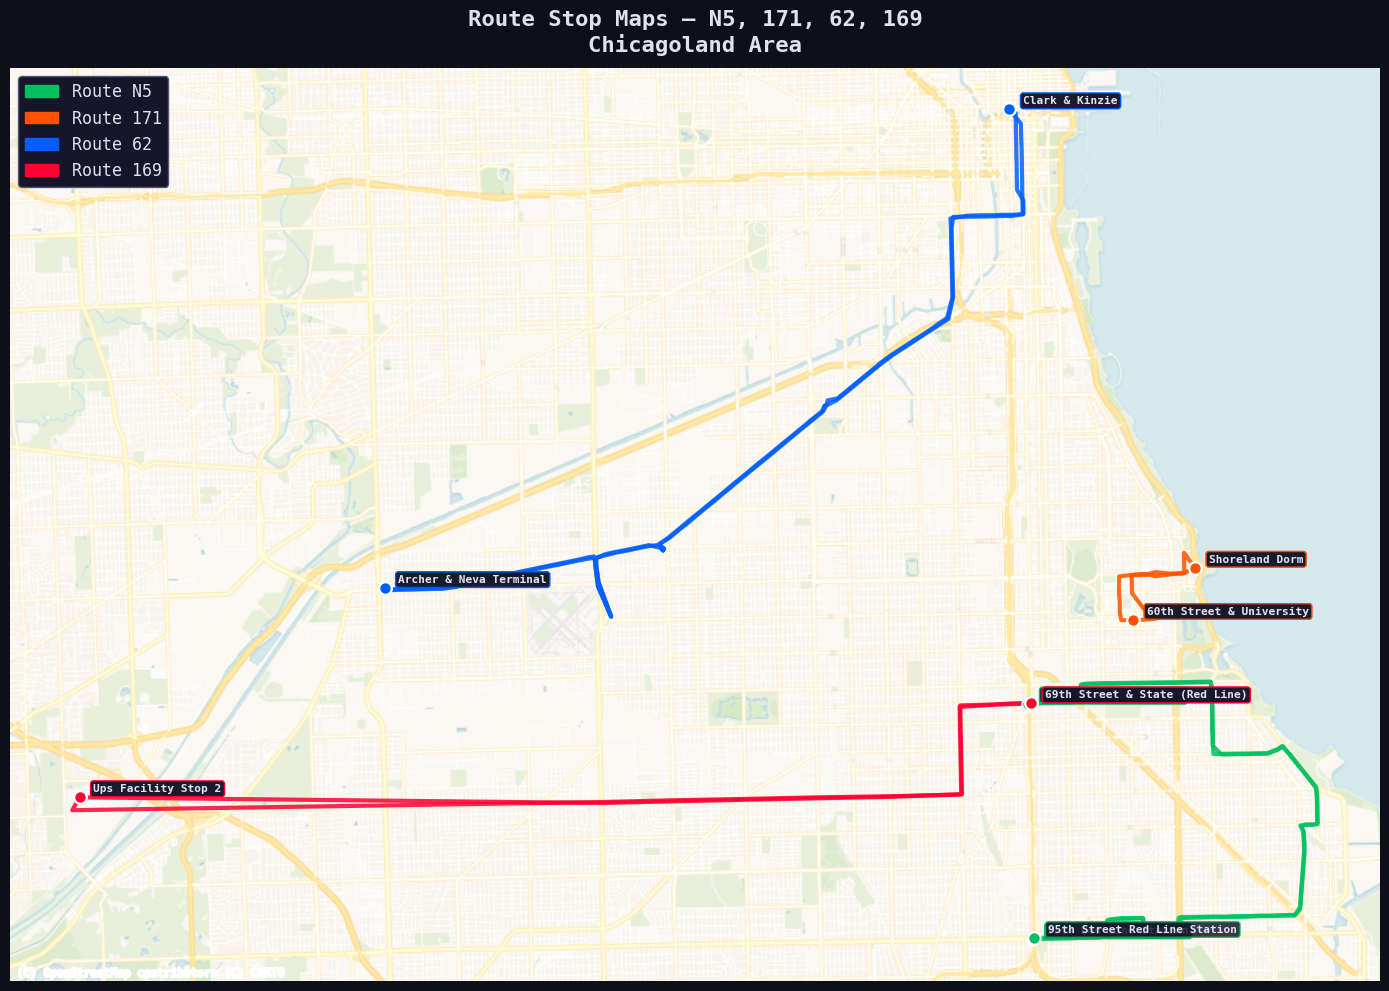

✓ Chicago route map saved


In [ ]:
import geopandas as gpd
import contextily as ctx
from shapely.geometry import LineString, Point
import warnings
warnings.filterwarnings('ignore')

ROUTES_TO_PLOT = ['N5', '171', '62', '169']
ROUTE_COLORS   = {'N5': "#00c161", '171': ORANGE, '62': BLUE, '169': RED}

# Building GeoDataFrame of route lines
route_lines = []
for route_id in ROUTES_TO_PLOT:
    route_data = static_data[static_data['route_id'] == route_id].copy()
    if len(route_data) == 0:
        continue

    # One representative trip per direction — most stops = most complete
    best_trips = (
        route_data.groupby(['direction', 'trip_id'])
        .size().reset_index(name='n_stops')
        .sort_values('n_stops', ascending=False)
        .groupby('direction').first().reset_index()
    )

    for _, row in best_trips.iterrows():
        trip_stops = (
            route_data[route_data['trip_id'] == row['trip_id']]
            .sort_values('stop_sequence')
            .drop_duplicates(subset=['stop_lat', 'stop_lon'])
        )
        if len(trip_stops) < 2:
            continue

        # Connecting stop coordinates into a route polyline
        coords = list(zip(trip_stops['stop_lon'], trip_stops['stop_lat']))
        route_lines.append({
            'route_id':  route_id,
            'direction': row['direction'],
            'geometry':  LineString(coords),
            'n_stops':   len(trip_stops),
        })

# Building GeoDataFrame of terminal stops
terminal_points = []
for route_id in ROUTES_TO_PLOT:
    route_data = static_data[static_data['route_id'] == route_id].copy()
    best_trips = (
        route_data.groupby(['direction', 'trip_id'])
        .size().reset_index(name='n_stops')
        .sort_values('n_stops', ascending=False)
        .groupby('direction').first().reset_index()
    )
    for _, row in best_trips.iterrows():
        trip_stops = (
            route_data[route_data['trip_id'] == row['trip_id']]
            .sort_values('stop_sequence')
            .drop_duplicates(subset=['stop_lat', 'stop_lon'])
        )
        if len(trip_stops) == 0:
            continue
        # Grabbing the first and last stop as terminals
        for idx in [0, -1]:
            stop = trip_stops.iloc[idx]
            terminal_points.append({
                'route_id':  route_id,
                'stop_name': stop['stop_name'],
                'geometry':  Point(stop['stop_lon'], stop['stop_lat']),
            })

# Reprojecting both layers to Web Mercator for basemap alignment
gdf_lines = gpd.GeoDataFrame(route_lines, crs='EPSG:4326').to_crs('EPSG:3857')
gdf_terminals = gpd.GeoDataFrame(terminal_points, crs='EPSG:4326').to_crs('EPSG:3857')

# Plotting the Chicago route map
fig, ax = plt.subplots(figsize=(14, 16), facecolor=BG)

# Drawing routes
for route_id in ROUTES_TO_PLOT:
    subset = gdf_lines[gdf_lines['route_id'] == route_id]
    subset.plot(ax=ax, color=ROUTE_COLORS[route_id],
                linewidth=3, alpha=0.85, zorder=3)

# Drawing terminal stops with labels
for route_id in ROUTES_TO_PLOT:
    subset = gdf_terminals[gdf_terminals['route_id'] == route_id]
    subset.plot(ax=ax, color=ROUTE_COLORS[route_id],
                markersize=80, zorder=5,
                edgecolor='white', linewidth=1.5)

    # Label terminals
    for _, row in subset.iterrows():
        ax.annotate(
            row['stop_name'],
            xy=(row.geometry.x, row.geometry.y),
            xytext=(10, 4), textcoords='offset points',
            fontsize=8, color=WHITE, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.25',
                      facecolor=PANEL, edgecolor=ROUTE_COLORS[route_id],
                      alpha=0.85),
            zorder=6
        )

# Chicago basemap — dark style fits the notebook theme
ctx.add_basemap(ax, source=ctx.providers.CartoDB.VoyagerNoLabels, zoom=12)

# Legend
legend_patches = [
    mpatches.Patch(color=ROUTE_COLORS[r], label=f'Route {r}')
    for r in ROUTES_TO_PLOT
]
ax.legend(handles=legend_patches, fontsize=12,
          facecolor=PANEL, edgecolor=GREY, labelcolor=WHITE,
          loc='upper left', framealpha=1)

ax.set_axis_off()
ax.set_title('Route Stop Maps — N5, 171, 62, 169\nChicagoland Area',
             color=WHITE, fontsize=16, fontweight='bold', pad=12)
fig.patch.set_facecolor(BG)

plt.tight_layout()
plt.savefig('report_route_map_chicago.png', dpi=300,
            bbox_inches='tight', facecolor=BG)
plt.show()
print('\u2713 Chicago route map saved')

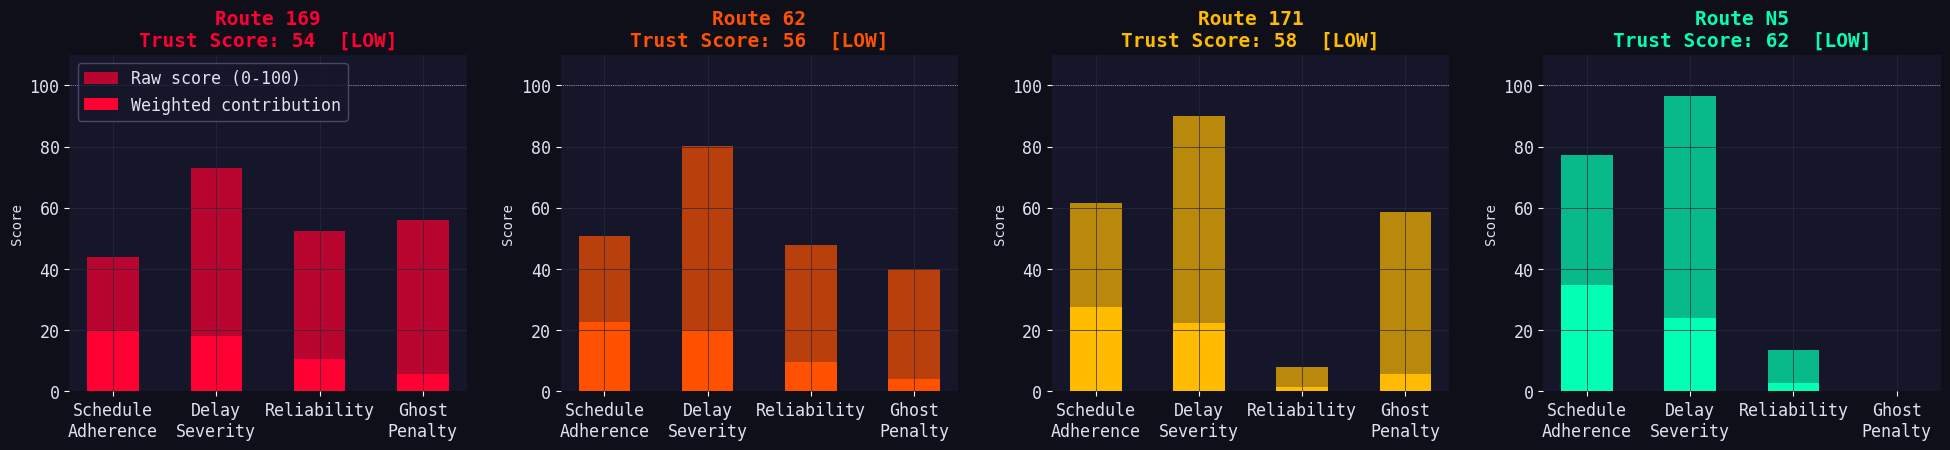

✓ Figure 3 saved


In [ ]:
# Plotting the pillar breakdown for the 4 worst-scoring routes

fig, axes = plt.subplots(1, 4, figsize=(20, 5), facecolor=BG)
ROUTE_COLORS = [RED, ORANGE, YELLOW, GREEN]

for col_i, (route_id, rcolor) in enumerate(zip(WORST4, ROUTE_COLORS)):
    row_data = df[df['route_id'] == route_id].iloc[0]
    ax_top = axes[col_i]

    pillars = ['Schedule\nAdherence','Delay\nSeverity','Reliability','Ghost\nPenalty']
    scores_p = [row_data['p_otp'], row_data['p_severity'],
                row_data['p_reliability'], row_data['p_ghost']]
    weights = [0.45, 0.25, 0.20, 0.10]
    # Raw scores overlaid with weighted contributions per pillar
    contrib  = [s*w for s, w in zip(scores_p, weights)]
    x_p = np.arange(len(pillars))

    ax_top.bar(x_p, scores_p, color=rcolor, alpha=0.7, width=0.5, label='Raw score (0-100)')
    ax_top.bar(x_p, contrib,  color=rcolor, alpha=1.0, width=0.5, label='Weighted contribution')
    ax_top.set_xticks(x_p)
    ax_top.set_xticklabels(pillars, fontsize=12)
    ax_top.set_ylim(0, 110)
    ax_top.set_ylabel('Score')
    ax_top.set_title(
        f'Route {route_id}\nTrust Score: {row_data["bus_trust_score"]:.0f}  [{row_data["trust_tier"]}]',
        color=rcolor, fontsize=14, fontweight='bold')
    ax_top.axhline(100, color=WHITE, lw=0.5, ls=':', alpha=1)
    if col_i == 0:
        ax_top.legend(fontsize=12, facecolor=PANEL, edgecolor=GREY,
                      labelcolor=WHITE, loc='upper left')

for ax_ in axes.flat:
    ax_.set_facecolor(PANEL)
    ax_.tick_params(axis='both', labelsize=12, labelcolor=WHITE)

plt.tight_layout(pad=2.5)
plt.savefig('pres_3_worst_routes.png', dpi=1000, bbox_inches='tight', facecolor=BG)
plt.show()
print('\u2713 Figure 3 saved')

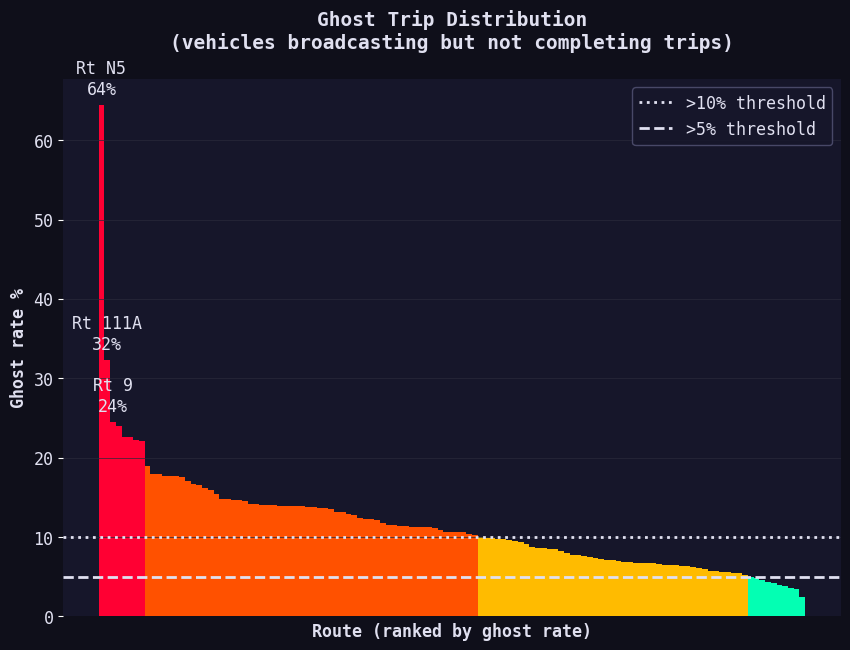

✓ Figure 4 saved


In [ ]:
# Plotting the ghost trip rate distribution across all routes

fig, ax = plt.subplots(figsize=(9, 7), facecolor=BG)

ghost_sorted = df.sort_values('ghost_rate_pct', ascending=False).reset_index(drop=True)
x = np.arange(len(ghost_sorted))

# Coloring bars by ghost rate severity
ghost_colors = [RED if g > 20 else ORANGE if g > 10 else YELLOW if g > 5 else GREEN
                for g in ghost_sorted['ghost_rate_pct']]
ax.bar(x, ghost_sorted['ghost_rate_pct'], color=ghost_colors, alpha=1, width=1.0)

# Labeling the worst offenders (>24%) inline
for i, row in ghost_sorted[ghost_sorted['ghost_rate_pct'] > 24].iterrows():
    ax.text(i, row['ghost_rate_pct'] + 0.8,
            f"Rt {row['route_id']}\n{row['ghost_rate_pct']:.0f}%",
            ha='center', va='bottom', color=WHITE, fontsize=12)

ax.axhline(10, color=WHITE, lw=2, ls='dotted', alpha=1, label='>10% threshold')
ax.axhline(5, color=WHITE, lw=2, ls='--',     alpha=1, label='>5% threshold')
ax.set_xlabel('Route (ranked by ghost rate)', fontsize=12, fontweight='bold')
ax.set_ylabel('Ghost rate %', fontsize=12, fontweight='bold')
ax.set_title('Ghost Trip Distribution\n(vehicles broadcasting but not completing trips)\n',
             color=WHITE, fontsize=14, fontweight='bold')
ax.tick_params(axis='both', labelsize=12, labelcolor=WHITE)
ax.legend(fontsize=12, facecolor=PANEL, edgecolor=GREY, labelcolor=WHITE)
ax.set_xticks([])
ax.set_facecolor(PANEL)

plt.tight_layout(pad=2.5)
plt.savefig('pres_4_ghost_distribution.png', dpi=1000, bbox_inches='tight', facecolor=BG)
plt.show()
print('\u2713 Figure 4 saved')

In [64]:
# Counting routes above the 10% ghost rate threshold
ghost_sorted[ghost_sorted['ghost_rate_pct'] > 10].shape

(66, 76)

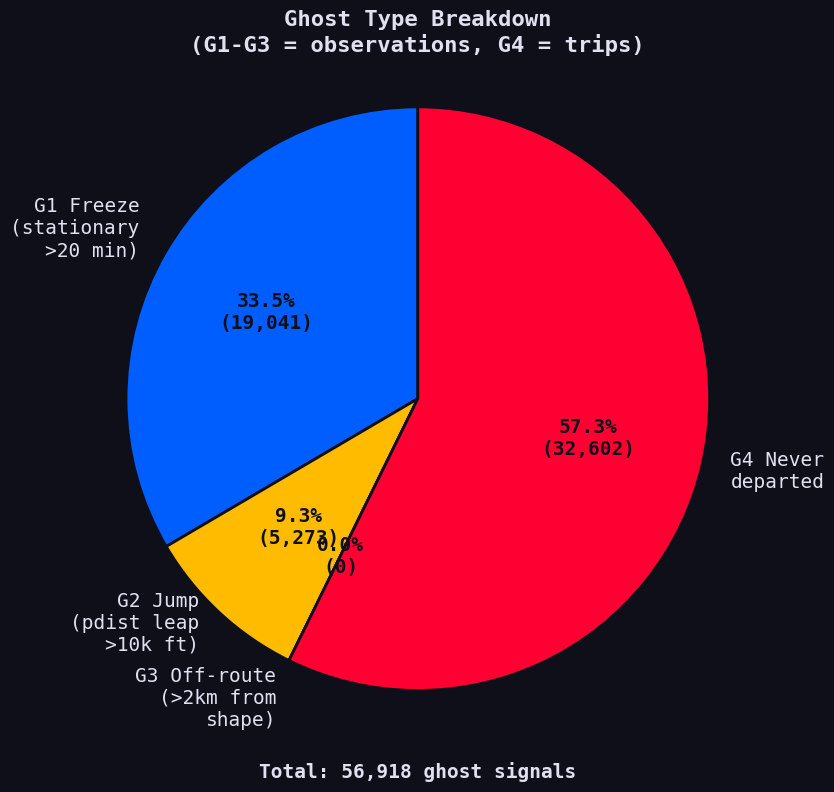

✓ Figure 5 saved


In [ ]:
# Plotting the ghost signal type breakdown as a pie chart
fig, ax = plt.subplots(figsize=(8, 8), facecolor=BG)

# Counting each ghost type from the raw observation data
ghost_obs = result[result['is_ghost']]
g1 = ghost_obs['ghost_freeze'].sum()
g2 = ghost_obs['ghost_jump'].sum()
g3 = ghost_obs['ghost_offroute'].sum()
g4 = (ghost_obs['match_type'] == 'ghost_trip').sum()

labels_g = ['G1 Freeze\n(stationary\n>20 min)\n',
            'G2 Jump\n(pdist leap\n>10k ft)\n',
            '\n\nG3 Off-route\n(>2km from\nshape)\n',
            'G4 Never\ndeparted']
values_g = [g1, g2, g3, g4]
colors_g = [BLUE, YELLOW, ORANGE, RED]

wedges, texts, autotexts = ax.pie(
    values_g, labels=labels_g, colors=colors_g,
    autopct=lambda p: f'{p:.1f}%\n({int(p/100*sum(values_g)):,})',
    startangle=90,
    wedgeprops=dict(width=1, edgecolor=BG, linewidth=2),
    textprops=dict(color=WHITE, fontsize=14),
)
for at in autotexts:
    at.set_fontsize(14)
    at.set_color(BG)
    at.set_fontweight('bold')

ax.set_title('Ghost Type Breakdown\n(G1-G3 = observations, G4 = trips)',
             color=WHITE, fontsize=16, fontweight='bold')
ax.text(0, -1.3, f'Total: {sum(values_g):,} ghost signals',
        ha='center', color=WHITE, fontsize=14, fontweight='bold')
ax.set_facecolor(PANEL)

plt.tight_layout(pad=2)
plt.axis('equal')
plt.savefig('pres_5_ghost_types.png', dpi=1000, bbox_inches='tight', facecolor=BG)
plt.show()
print('\u2713 Figure 5 saved')

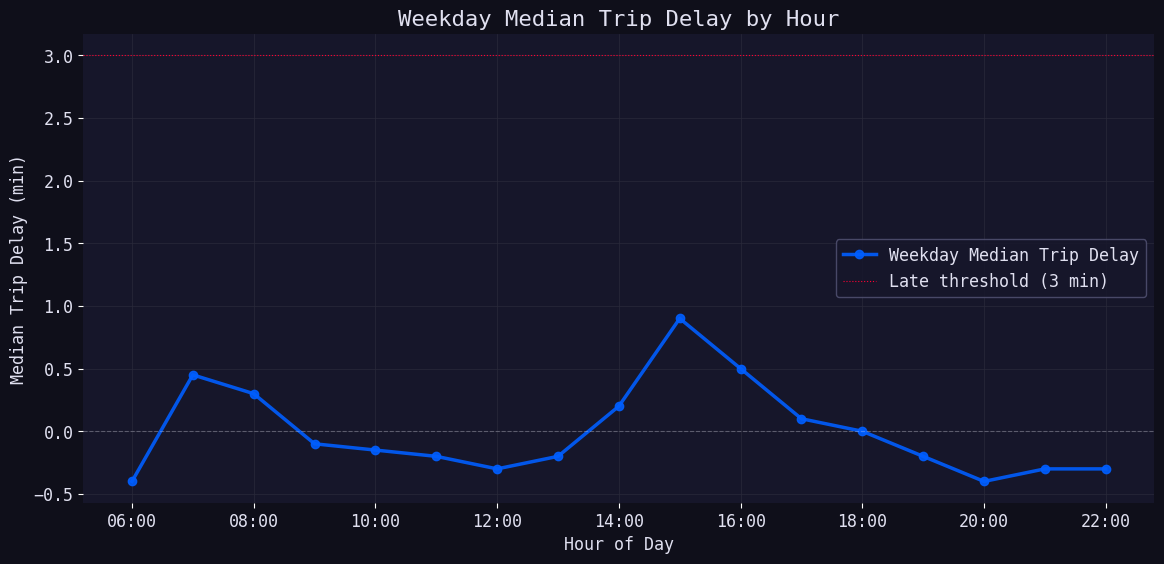

✓ Figure 6 saved


In [15]:
# Plotting the weekday median trip delay by hour

# Filtering to complete weekdays within operating hours
INCOMPLETE_DATES = [pd.Timestamp('2026-03-06').date()]

trips_wd = trips[
    ~trips['is_weekend'] &
    trips['hour'].notna() &
    (trips['hour'] >= 6) &
    (trips['hour'] <= 22) &
    ~trips['date'].isin(INCOMPLETE_DATES)
]
hourly_median = trips_wd.groupby('hour')['delay_median'].median()

fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG)
ax.plot(hourly_median.index, hourly_median.values,
        color=BLUE, lw=2.5, marker='o', markersize=6,
        label='Weekday Median Trip Delay', alpha=0.9)
ax.axhline(0, color=WHITE, lw=0.8, ls='--', alpha=0.3)
ax.axhline(3, color=RED,   lw=0.8, ls=':',  alpha=1, label='Late threshold (3 min)')

ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('Median Trip Delay (min)', fontsize=12)
ax.set_xticks(range(6, 24, 2))
ax.set_xticklabels([f'{h:02d}:00' for h in range(6, 24, 2)], fontsize=12)
ax.set_title('Weekday Median Trip Delay by Hour', fontsize=16, color=WHITE)
ax.set_facecolor(PANEL)
ax.legend(fontsize=12, facecolor=PANEL, edgecolor=GREY, labelcolor=WHITE)
ax.tick_params(axis='both', labelsize=12, labelcolor=WHITE)

plt.tight_layout(pad=2)
plt.savefig('pres_6_weekday_median_delay_by_hour.png', dpi=1000, bbox_inches='tight', facecolor=BG)
plt.show()
print('\u2713 Figure 6 saved')

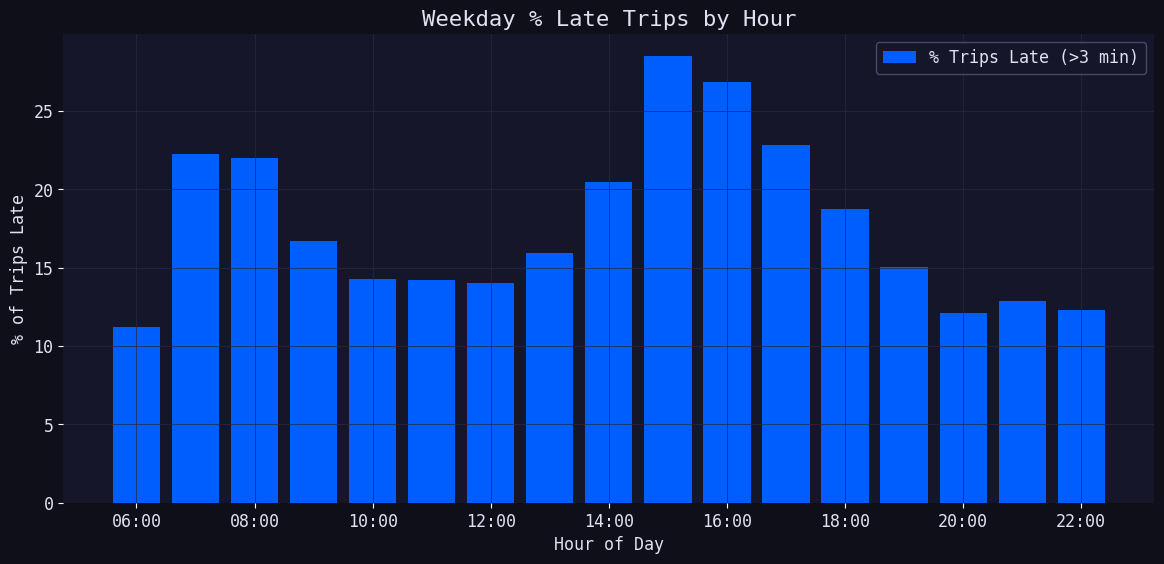

✓ Figure 7 saved


In [16]:
# Plotting the weekday percentage of late trips by hour

hourly_pct_late = trips_wd.groupby('hour')['is_late'].mean() * 100

fig, ax = plt.subplots(figsize=(12, 6), facecolor=BG)
ax.bar(hourly_pct_late.index, hourly_pct_late.values,
       width=0.8, color=BLUE, alpha=1, label='% Trips Late (>3 min)')

ax.set_xlabel('Hour of Day', fontsize=12)
ax.set_ylabel('% of Trips Late', fontsize=12)
ax.set_xticks(range(6, 24, 2))
ax.set_xticklabels([f'{h:02d}:00' for h in range(6, 24, 2)], fontsize=12)
ax.set_title('Weekday % Late Trips by Hour', fontsize=16, color=WHITE)
ax.set_facecolor(PANEL)
ax.legend(fontsize=12, facecolor=PANEL, edgecolor=GREY, labelcolor=WHITE)
ax.tick_params(axis='both', labelsize=12, labelcolor=WHITE)

plt.tight_layout(pad=2)
plt.savefig('pres_7_weekday_pct_late_by_hour.png', dpi=1000, bbox_inches='tight', facecolor=BG)
plt.show()
print('\u2713 Figure 7 saved')

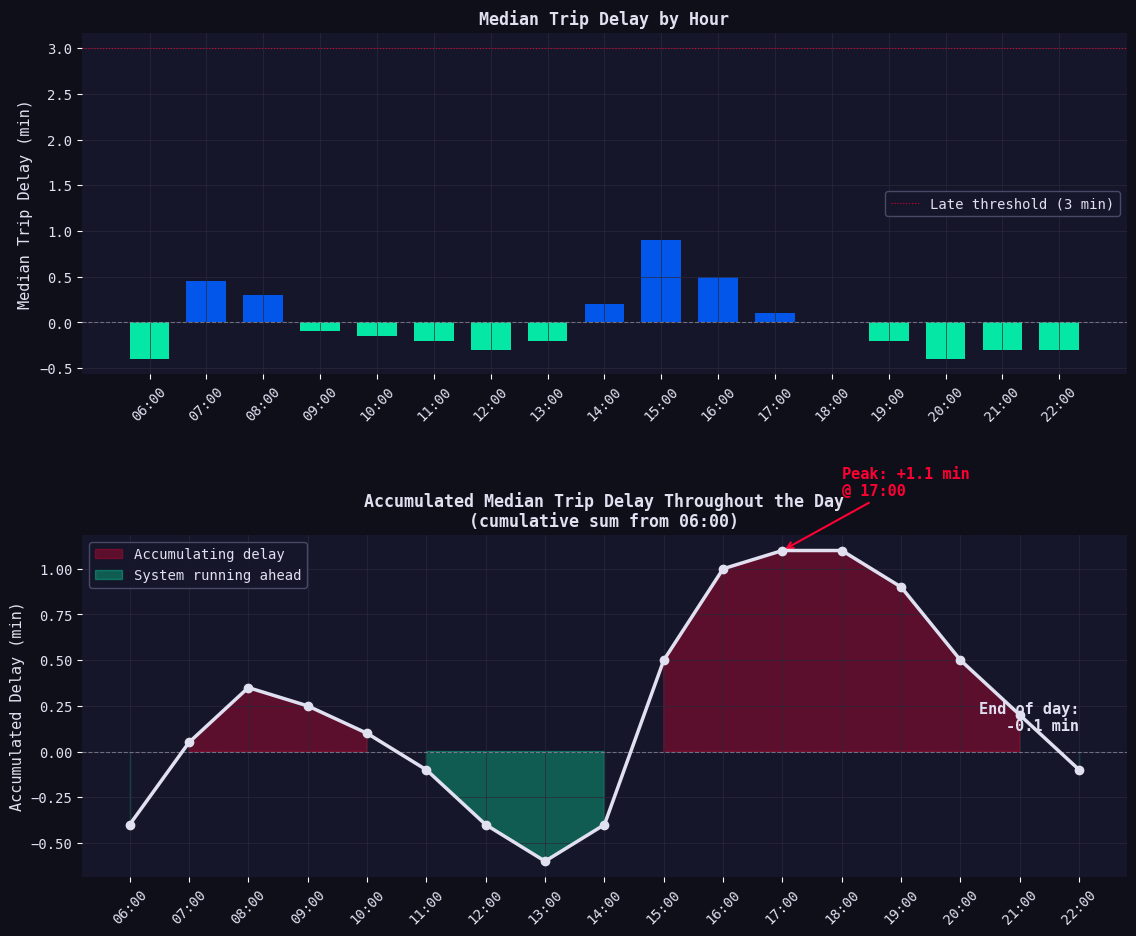

In [ ]:
# Plotting the accumulated delay throughout the service day
# Shows how delay builds from 06:00 as a cumulative sum

hourly_median = trips_wd.groupby('hour')['delay_median'].median()

# Cumulative sum starting from 06:00
accum_delay = hourly_median.cumsum()

fig, axes = plt.subplots(2, 1, figsize=(12, 10), facecolor=BG)

# Top: hourly median delay bar chart
ax = axes[0]
# Coloring each hour bar by whether it's late, borderline, early, or neutral
colors = [RED if v > 3 else ORANGE if v > 1 else GREEN if v < 0 else BLUE
          for v in hourly_median.values]

ax.bar(hourly_median.index, hourly_median.values, color=colors, alpha=0.9, width=0.7)
ax.axhline(0, color=WHITE,  lw=0.8, ls='--', alpha=0.4)
ax.axhline(3, color=RED,    lw=0.8, ls=':',  alpha=0.8, label='Late threshold (3 min)')
ax.set_xticks(range(6, 23, 1))
ax.set_xticklabels([f'{h:02d}:00' for h in range(6, 23, 1)], rotation=45, fontsize=10)
ax.set_ylabel('Median Trip Delay (min)', fontsize=11)
ax.set_title('Median Trip Delay by Hour', color=WHITE, fontsize=12, fontweight='bold')
ax.legend(fontsize=10, facecolor=PANEL, edgecolor=GREY, labelcolor=WHITE)
ax.set_facecolor(PANEL)
ax.tick_params(labelsize=10, labelcolor=WHITE)

#  Bottom: cumulative delay with fill 
ax = axes[1]

# Shading red where the system is falling behind, green where it's ahead
ax.fill_between(accum_delay.index, accum_delay.values, 0,
                where=accum_delay.values >= 0,
                color=RED, alpha=0.3, label='Accumulating delay')
ax.fill_between(accum_delay.index, accum_delay.values, 0,
                where=accum_delay.values < 0,
                color=GREEN, alpha=0.3, label='System running ahead')

ax.plot(accum_delay.index, accum_delay.values,
        color=WHITE, lw=2.5, marker='o', markersize=6, zorder=5)

# Annotating the peak delay hour and end-of-day total
peak_hour = accum_delay.idxmax()
peak_val  = accum_delay.max()
final_val = accum_delay.iloc[-1]

ax.annotate(f'Peak: +{peak_val:.1f} min\n@ {peak_hour:02d}:00',
            xy=(peak_hour, peak_val),
            xytext=(peak_hour + 1, peak_val + 0.3),
            color=RED, fontsize=11, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=RED, lw=1.5))

ax.text(accum_delay.index[-1], final_val + 0.2,
        f'End of day:\n{final_val:+.1f} min',
        ha='right', va='bottom', color=WHITE,
        fontsize=11, fontweight='bold')

ax.axhline(0, color=WHITE, lw=0.8, ls='--', alpha=0.4)
ax.set_xticks(range(6, 23, 1))
ax.set_xticklabels([f'{h:02d}:00' for h in range(6, 23, 1)], rotation=45, fontsize=10)
ax.set_ylabel('Accumulated Delay (min)', fontsize=11)
ax.set_title('Accumulated Median Trip Delay Throughout the Day\n(cumulative sum from 06:00)',
             color=WHITE, fontsize=12, fontweight='bold')
ax.legend(fontsize=10, facecolor=PANEL, edgecolor=GREY, labelcolor=WHITE)
ax.set_facecolor(PANEL)
ax.tick_params(labelsize=10, labelcolor=WHITE)

plt.tight_layout(pad=3)
plt.savefig('report_accumulated_delay.png', dpi=300, bbox_inches='tight', facecolor=BG)
plt.show()

# Route 201 Focus

In [ ]:
# Setting up Route 201 observation and trip subsets for focused analysis

# Observation-level subset for stop corridor analysis
r201 = clean[clean['route_id'] == '201'].copy()
r201['tmstmp_dt'] = pd.to_datetime(r201['tmstmp'])
r201['hour'] = r201['tmstmp_dt'].dt.hour
r201['dow'] = r201['tmstmp_dt'].dt.day_name()
r201['date'] = r201['tmstmp_dt'].dt.date
r201['sched_dep_hour'] = (r201['scheduled_departure_stop1'] // 60).astype('Int64')
r201['tod'] = r201['sched_dep_hour'].apply(
    lambda h: get_tod(h) if pd.notna(h) else get_tod(0)
)

# Trip-level subset — reusing the trips df already computed
trips_201 = trips[trips['route_id'] == '201'].copy()

BUCKET_COLORS = [BLUE, GREEN, ORANGE, RED]
BUCKET_ORDER  = ['Early (<-1 min)', 'On Time (-1 to +3)', 'Late (3-15 min)', 'Very Late (>15 min)']

# Binning each trip into an OTP bucket
trips_201['otp_bucket'] = pd.cut(
    trips_201['delay_median'],
    bins=[-np.inf, -1, 3, 15, np.inf],
    labels=BUCKET_ORDER
)

r201_ghost_rate = perf.loc[perf['route_id'] == '201', 'ghost_rate_pct'].values[0]
r201_n_ghosts   = perf.loc[perf['route_id'] == '201', 'n_ghost_trips'].values[0]

print(f'Route 201 trips: {len(trips_201):,}')
print('\nOTP bucket counts (trip-level):')
print(trips_201['otp_bucket'].value_counts().reindex(BUCKET_ORDER))
print(f'\nGhost rate: {r201_ghost_rate:.1f}%  ({r201_n_ghosts:.0f} ghost trips)')

Route 201 trips: 841

OTP bucket counts (trip-level):
otp_bucket
Early (<-1 min)         60
On Time (-1 to +3)     420
Late (3-15 min)        345
Very Late (>15 min)     16
Name: count, dtype: int64

Ghost rate: 6.9%  (62 ghost trips)


In [ ]:
# Grouping the Route 201 trip data by date and time-of-day to get daily medians
daily_tod_median = (
    trips_201.groupby(['date', 'tod'], observed=True)['delay_median']
    .median()
    .reset_index()
)

# Pivoting to a date × TOD matrix for boxplot use
daily_tod_median_pivot = (
    daily_tod_median
    .pivot(index='date', columns='tod', values='delay_median')
    .reindex(columns=TOD_ORDER)
)

print(daily_tod_median_pivot.round(1))

tod         Early Morning  AM Peak  Midday  PM Peak  Evening
date                                                        
2026-02-20            NaN      NaN     NaN      7.6      6.0
2026-02-21            NaN      1.3     2.5      2.8      2.1
2026-02-23           -0.9      1.4     1.4      2.0     -0.0
2026-02-24            1.2      2.2     2.0      2.4     -0.8
2026-02-25           -0.2      2.4     4.2      4.7      2.5
2026-02-26           -0.8      1.6     3.2      2.9      4.2
2026-02-27           -0.3      1.3     0.8      5.9      9.0
2026-02-28            NaN      0.2     2.8      4.0      0.4
2026-03-02           -0.4      1.4     1.7      2.0      3.2
2026-03-03            1.2      2.6     5.2      4.4      0.6
2026-03-04           -0.0      3.8     5.4      5.2      8.1
2026-03-05            0.0      2.1     4.2      2.2      2.5
2026-03-06            0.3      2.1     1.1      2.0      NaN


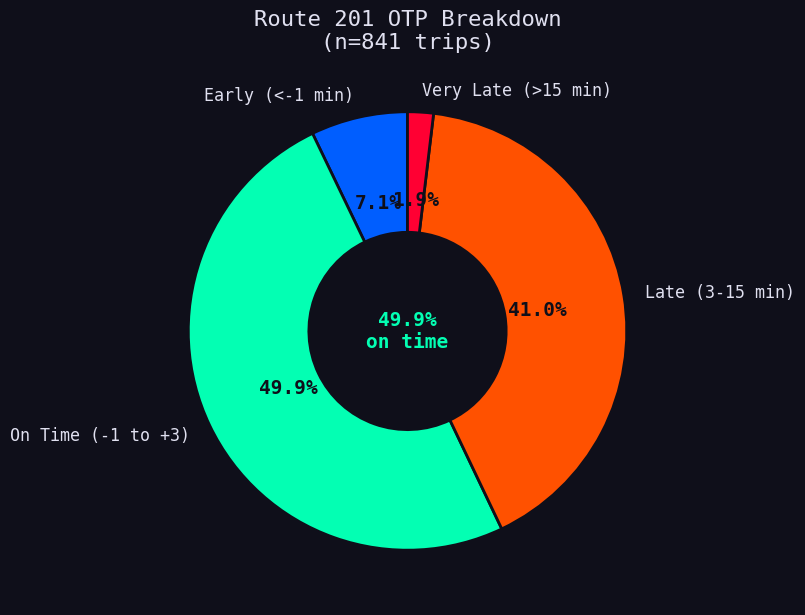

✓ Figure saved


In [ ]:
# Plotting the Route 201 OTP breakdown as a donut chart
bucket_counts = trips_201['otp_bucket'].value_counts().reindex(BUCKET_ORDER)
on_time_pct = bucket_counts['On Time (-1 to +3)'] / bucket_counts.sum() * 100

fig, ax = plt.subplots(figsize=(8, 8), facecolor=BG)

wedges, texts, autotexts = ax.pie(
    bucket_counts, labels=BUCKET_ORDER, colors=BUCKET_COLORS,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.55, edgecolor=BG, linewidth=2),
    textprops=dict(color=WHITE, fontsize=12)
)
# Matching each percentage label color to its bucket
for at, col in zip(autotexts, BUCKET_COLORS):
    at.set_color(BG)
    at.set_fontweight('bold')
    at.set_fontsize(14)

ax.set_title(f'Route 201 OTP Breakdown\n(n={bucket_counts.sum():,} trips)',
             color=WHITE, fontsize=16)
# On-time percentage in the donut center
ax.text(0, 0, f'{on_time_pct:.1f}%\non time',
        ha='center', va='center', color=GREEN, fontsize=14, fontweight='bold')
ax.set_facecolor(PANEL)

plt.tight_layout()
plt.savefig('pres_201_otp_donut.png', dpi=1000, bbox_inches='tight', facecolor=BG)
plt.show()
print('\u2713 Figure saved')

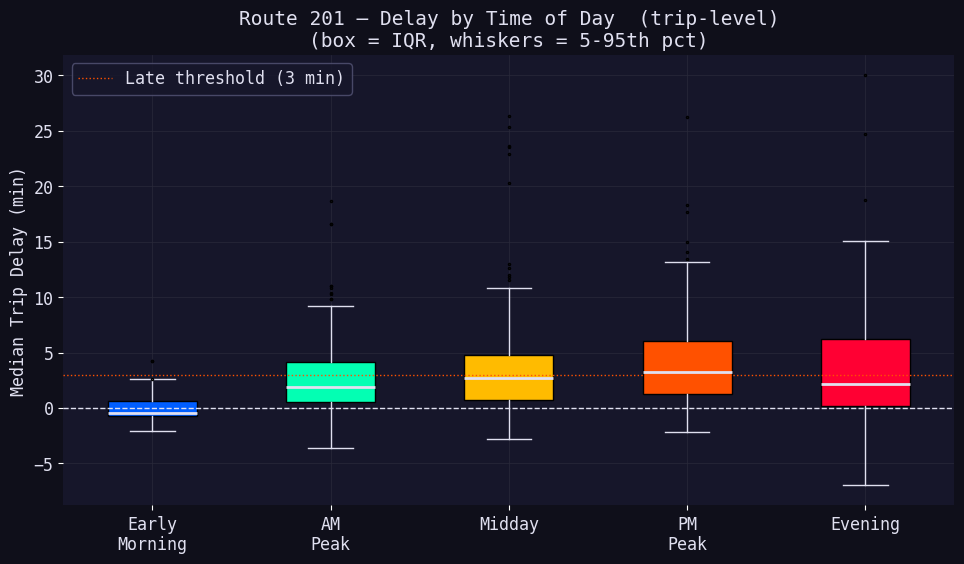

✓ Figure saved


In [ ]:
# Plotting the Route 201 delay distribution by time-of-day as a boxplot
TOD_COLORS = [BLUE, GREEN, YELLOW, ORANGE, RED]
# Clipping extreme delays to keep the boxplot readable
bp_data    = [trips_201[trips_201['tod'] == t]['delay_median'].clip(-15, 30).dropna()
              for t in TOD_ORDER]

fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
bp = ax.boxplot(bp_data, patch_artist=True, notch=False,
                medianprops=dict(color=WHITE, lw=2),
                whiskerprops=dict(color=WHITE),
                capprops=dict(color=WHITE),
                flierprops=dict(marker='.', color=GREY, markersize=3, alpha=1))

for patch, col in zip(bp['boxes'], TOD_COLORS):
    patch.set_facecolor(col)
    patch.set_alpha(1)

ax.set_xticklabels([t.replace(' ', '\n') for t in TOD_ORDER], fontsize=12)
ax.set_ylabel('Median Trip Delay (min)', fontsize=12)
ax.set_title('Route 201 — Delay by Time of Day  (trip-level)\n(box = IQR, whiskers = 5-95th pct)',
             color=WHITE, fontsize=14)
ax.axhline(0, color=WHITE,  lw=1, ls='--', alpha=1)
ax.axhline(3, color=ORANGE, lw=1, ls=':',  alpha=1, label='Late threshold (3 min)')
ax.legend(fontsize=12, facecolor=PANEL, edgecolor=GREY, labelcolor=WHITE)
ax.tick_params(axis='both', labelsize=12, labelcolor=WHITE)
ax.set_facecolor(PANEL)

plt.tight_layout(pad=2)
plt.savefig('pres_201_tod_boxplot.png', dpi=1000, bbox_inches='tight', facecolor=BG)
plt.show()
print('\u2713 Figure saved')

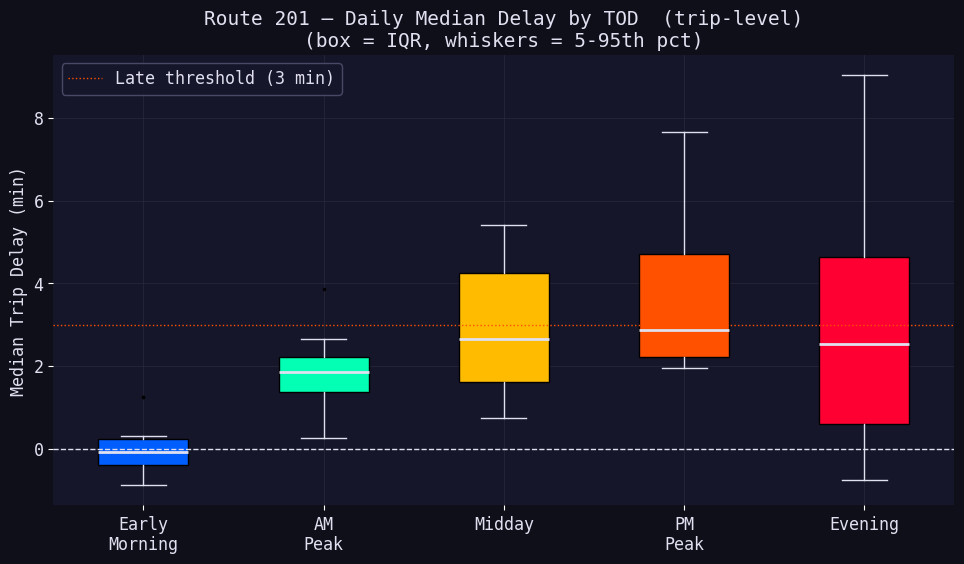

✓ Figure saved


In [ ]:
# Plotting the Route 201 daily median delay by TOD — day-level spread

TOD_COLORS       = [BLUE, GREEN, YELLOW, ORANGE, RED]
bp_data_grouped  = [daily_tod_median_pivot[t].dropna() for t in TOD_ORDER]

fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
bp = ax.boxplot(bp_data_grouped, patch_artist=True, notch=False,
                medianprops=dict(color=WHITE, lw=2),
                whiskerprops=dict(color=WHITE),
                capprops=dict(color=WHITE),
                flierprops=dict(marker='.', color=GREY, markersize=3, alpha=1))

for patch, col in zip(bp['boxes'], TOD_COLORS):
    patch.set_facecolor(col)
    patch.set_alpha(1)

ax.set_xticklabels([t.replace(' ', '\n') for t in TOD_ORDER], fontsize=12)
ax.set_ylabel('Median Trip Delay (min)', fontsize=12)
ax.set_title('Route 201 — Daily Median Delay by TOD  (trip-level)\n(box = IQR, whiskers = 5-95th pct)',
             color=WHITE, fontsize=14)
ax.axhline(0, color=WHITE,  lw=1, ls='--', alpha=1)
ax.axhline(3, color=ORANGE, lw=1, ls=':',  alpha=1, label='Late threshold (3 min)')
ax.legend(fontsize=12, facecolor=PANEL, edgecolor=GREY, labelcolor=WHITE)
ax.set_facecolor(PANEL)
ax.tick_params(axis='both', labelsize=12, labelcolor=WHITE)

plt.tight_layout(pad=2)
plt.savefig('pres_201_daily_tod_boxplot.png', dpi=1000, bbox_inches='tight', facecolor=BG)
plt.show()
print('\u2713 Figure saved')

## Route 201 — Stop-Level Analysis  (observation-level)

In [ ]:
# Checking which stop-related columns are available before corridor analysis

stop_cols = [c for c in clean.columns if any(x in c.lower()
             for x in ['stop','stpid','stpnm','next','prev'])]
print('Stop-related columns:', stop_cols)
print('\nSample prev_stop_name values:')
print(r201['prev_stop_name'].value_counts().head(10))
print('\nSample next_stop_name values:')
print(r201['next_stop_name'].value_counts().head(10))

Stop-related columns: ['stop_id', 'first_stop_name', 'scheduled_departure_stop1', 'prev_stop_name', 'next_stop_name']

Sample prev_stop_name values:
prev_stop_name
Old Orchard Rd & Skokie Blvd        2103
Rogers & Hermitage                  1474
Paulina & Howard Terminal            873
Sheridan & Lincoln                   667
4700 W Old Orchard Rd                655
Church & Chicago Avenue              626
Sheridan & Haven                     625
Sheridan & Foster                    550
Central Street & Crawford            495
Old Orchard Mall - Bloomingdales     475
Name: count, dtype: int64

Sample next_stop_name values:
next_stop_name
Old Orchard Mall - Macys        1988
Paulina & Howard Terminal       1474
Howard & Chicago Avenue          873
Central Street & Crawford        814
Old Orchard Rd & Skokie Blvd     689
Sheridan & Lincoln               662
Sheridan & Haven                 649
Sheridan & Emerson               626
Howard & Ridge                   624
Ridge & Oakton       

In [ ]:
# Filtering Route 201 observations to the Sheridan corridor stops

STOPS = {
    'Sheridan & Emerson': ('NB',   'Emerson'),
    'Sheridan & Foster':  ('NB/SB','Foster'),
    'Sheridan & Haven':   ('NB/SB','Haven'),
    'Sheridan & Lincoln': ('NB/SB','Lincoln'),
}

# Keeping obs where any of these stops appears as next or previous
r201_stops = r201[
    r201['next_stop_name'].isin(STOPS.keys()) |
    r201['prev_stop_name'].isin(STOPS.keys())
].copy()

# Resolving which stop is the reference and whether bus is approaching or departing
r201_stops['stop_name'] = np.where(
    r201_stops['next_stop_name'].isin(STOPS.keys()),
    r201_stops['next_stop_name'],
    r201_stops['prev_stop_name']
)
r201_stops['at_stop_type'] = np.where(
    r201_stops['next_stop_name'].isin(STOPS.keys()),
    'approaching', 'departed'
)

print('Observations per stop:')
print(r201_stops.groupby(['stop_name','at_stop_type']).size().unstack(fill_value=0))
print('\nDelay summary per stop:')
print(r201_stops.groupby('stop_name')['delay_minutes']
      .agg(['count','median','mean','std']).round(2))

Observations per stop:
at_stop_type        approaching  departed
stop_name                                
Sheridan & Emerson          626         0
Sheridan & Foster           408       300
Sheridan & Haven            649         0
Sheridan & Lincoln          662       268

Delay summary per stop:
                    count  median  mean   std
stop_name                                    
Sheridan & Emerson    626     4.0  4.52  3.77
Sheridan & Foster     708     2.1  2.98  4.69
Sheridan & Haven      649     2.6  3.25  4.49
Sheridan & Lincoln    930     3.6  4.09  4.52


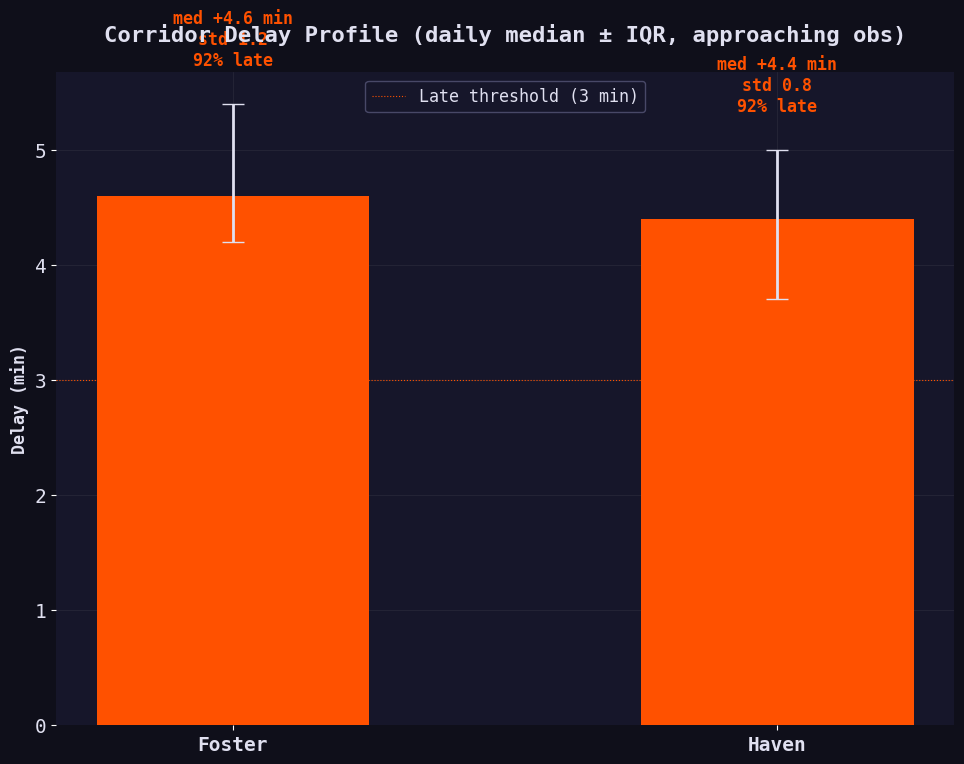

✓ Figure saved


In [ ]:
# Plotting the Route 201 corridor delay profile at Foster and Haven stops

STOP_ORDER = ['Sheridan & Foster', 'Sheridan & Haven']
STOP_SHORT = ['Foster', 'Haven']

# Using northbound approaching observations only
r201_appr = r201_stops[
    (r201_stops['at_stop_type'] == 'approaching') &
    (r201_stops['des'] == 'Old Orchard')
].copy()

# Aggregating to daily medians per stop, then computing summary stats
daily_stop_median = (
    r201_appr.groupby(['date', 'stop_name'])['delay_minutes']
    .median().reset_index()
)

stop_stats = (
    daily_stop_median.groupby('stop_name')['delay_minutes']
    .agg(['median','mean','std',
          lambda x: x.quantile(0.25),
          lambda x: x.quantile(0.75),
          lambda x: (x > 3).mean() * 100,
          lambda x: (x > 15).mean() * 100,
          'count'])
    .reindex(STOP_ORDER)
)
stop_stats.columns = ['median','mean','std','q25','q75','pct_late','pct_very_late','n']

fig, ax = plt.subplots(figsize=(10, 8), facecolor=BG)
x        = np.arange(len(STOP_ORDER))
bar_cols = [ORANGE, ORANGE]

ax.bar(x, stop_stats['median'], color=bar_cols, alpha=1, width=0.5, zorder=3)
# Error bars showing IQR spread
ax.errorbar(x, stop_stats['median'],
            yerr=[stop_stats['median'] - stop_stats['q25'],
                  stop_stats['q75']    - stop_stats['median']],
            fmt='none', color=WHITE, capsize=8, lw=2, zorder=4)

# Annotating median, std, and % late above each bar
for i, (s, row) in enumerate(stop_stats.iterrows()):
    ax.text(i, row['q75'] + 0.3,
            f"med {row['median']:+.1f} min\nstd {row['std']:.1f}\n{row['pct_late']:.0f}% late",
            ha='center', va='bottom', fontsize=12, color=bar_cols[i], fontweight='bold')

ax.axhline(0, color=WHITE,  lw=0.7, ls='--', alpha=1)
ax.axhline(3, color=ORANGE, lw=0.8, ls=':',  alpha=1, label='Late threshold (3 min)')
ax.set_xticks(x)
ax.set_xticklabels(STOP_SHORT, fontsize=12, fontweight='bold')
ax.set_ylabel('Delay (min)', color=WHITE, fontsize=12, fontweight='bold')
ax.set_title('Corridor Delay Profile (daily median \u00b1 IQR, approaching obs)\n',
             color=WHITE, fontsize=16, fontweight='bold')
ax.legend(fontsize=12, facecolor=PANEL, edgecolor=GREY, labelcolor=WHITE)
ax.tick_params(axis='both', labelsize=14, labelcolor=WHITE)
ax.set_facecolor(PANEL)

plt.tight_layout(pad=2)
plt.savefig('pres_201_corridor_delay_profile.png', dpi=1000, bbox_inches='tight', facecolor=BG)
plt.show()
print('\u2713 Figure saved')

# Ridership Score

In [ ]:
# Loading the ridership dataset and previewing highest-ridership routes
ridership = pd.read_csv('Datasets/ridership.csv')
ridership.sort_values(by='rides', ascending=False)

In [ ]:
# Parsing dates, cleaning the rides column, and casting route to string
ridership['date'] = pd.to_datetime(ridership['date'])
ridership['rides'] = ridership['rides'].str.replace(',','').astype(int)
ridership['route'] = ridership['route'].astype(str)

In [ ]:
# Filtering to 2025 data only and checking route coverage
ridership = ridership[ridership.date >= '2025-01-01'].reset_index(drop=True)
ridership.route.value_counts()

In [ ]:
# Aggregating the ridership data by route — mean daily rides per route
ridership_by_date = pd.DataFrame(ridership.groupby(['route'])['rides'].mean().reset_index())
ridership_by_date

In [ ]:
# Adding a log-transformed ridership column and checking its distribution
ridership_by_date['log_ridership'] = np.log1p(ridership_by_date.rides)

plt.hist(ridership_by_date.log_ridership, bins=30)
plt.show()
ridership_by_date.to_csv('metrics_results/ridership_results.csv')

In [ ]:
# Reloading full results and ridership data for the trust vs ridership figure
metrics  = pd.read_csv('metrics_results/mar1_full_results.csv')
ridership_by_date = pd.read_csv('metrics_results/ridership_results.csv')

In [ ]:
# Recomputing bus trust score on the full metrics dataset
metrics['bus_trust_score'] = (
    0.45 * metrics['p_otp'] +
    0.25 * metrics['p_severity'] +
    0.20 * metrics['p_reliability'] +
    0.10 * metrics['p_ghost']
)

In [ ]:
# Normalizing ridership to a 0-1 scale for comparison with trust score
ridership_by_date['ridership_score'] = (ridership_by_date.rides - ridership_by_date.rides.min()) / (ridership_by_date.rides.max() - ridership_by_date.rides.min())

In [ ]:
# Joining ridership scores onto the metrics dataframe by route
metrics = metrics.merge(ridership_by_date, right_on='route', left_on='route_id', how='left')

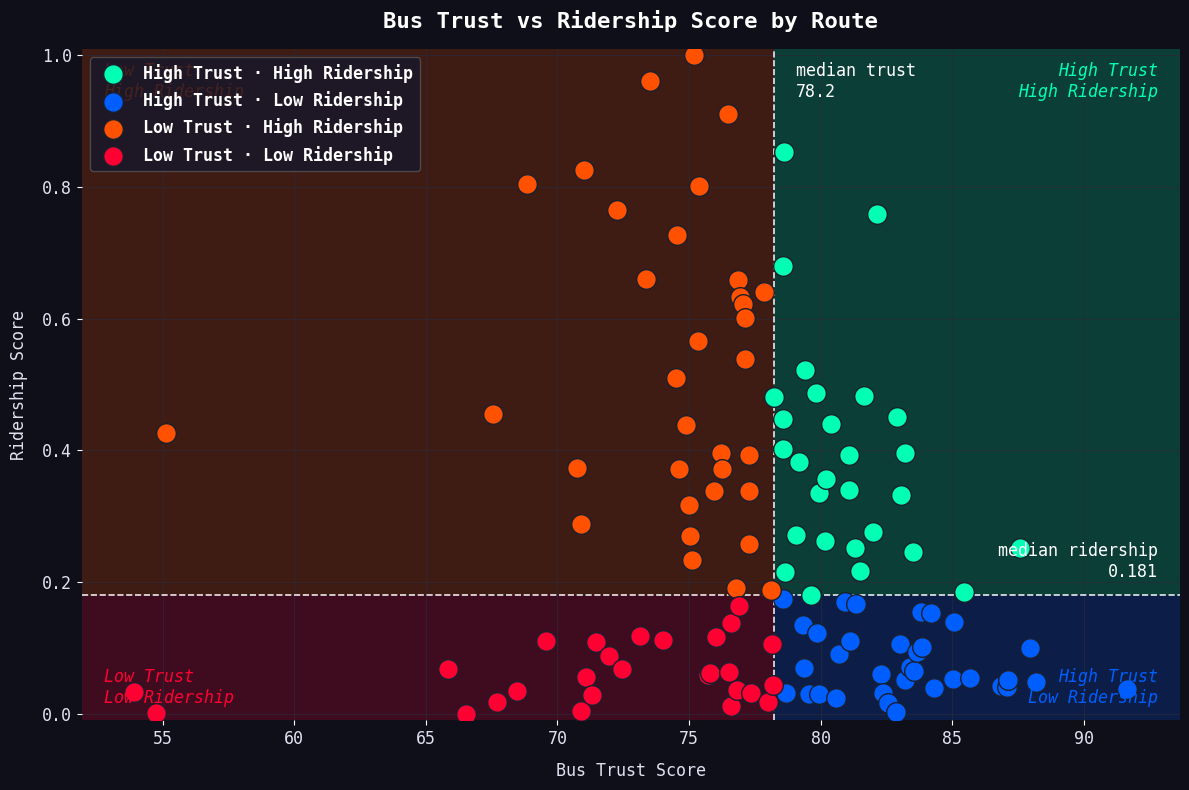

✓ Figure saved


In [ ]:
# Plotting Bus Trust Score vs Ridership Score — quadrant scatter

df_m = metrics.copy()

# Median split thresholds for quadrant assignment
trust_mid     = df_m['bus_trust_score'].median()
ridership_mid = df_m['ridership_score'].median()

def assign_quadrant(row):
    """This function takes a route row with trust and ridership scores, determines which of the four quadrants it falls in, and returns the quadrant label string."""
    hi_t = row['bus_trust_score'] >= trust_mid
    hi_r = row['ridership_score']  >= ridership_mid
    if   hi_t and hi_r:     return 'High Trust\nHigh Ridership'
    elif hi_t and not hi_r: return 'High Trust\nLow Ridership'
    elif not hi_t and hi_r: return 'Low Trust\nHigh Ridership'
    else:                   return 'Low Trust\nLow Ridership'

df_m['quadrant'] = df_m.apply(assign_quadrant, axis=1)

quad_colors = {
    'High Trust\nHigh Ridership': GREEN,
    'High Trust\nLow Ridership':  BLUE,
    'Low Trust\nHigh Ridership':  ORANGE,
    'Low Trust\nLow Ridership':   RED,
}
quad_labels = {
    'High Trust\nHigh Ridership': 'High Trust · High Ridership',
    'High Trust\nLow Ridership':  'High Trust · Low Ridership',
    'Low Trust\nHigh Ridership':  'Low Trust · High Ridership',
    'Low Trust\nLow Ridership':   'Low Trust · Low Ridership',
}

fig, ax = plt.subplots(figsize=(12, 8))

xlim = (df_m['bus_trust_score'].min()-2, df_m['bus_trust_score'].max()+2)
ylim = (df_m['ridership_score'].min()-0.01, df_m['ridership_score'].max()+0.01)

# Shading the four quadrants
shade_quads = [
    (xlim[0], trust_mid, ylim[0], ridership_mid, RED,    0.2),
    (trust_mid, xlim[1], ylim[0], ridership_mid, BLUE,   0.2),
    (xlim[0], trust_mid, ridership_mid, ylim[1], ORANGE, 0.2),
    (trust_mid, xlim[1], ridership_mid, ylim[1], GREEN,  0.2),
]
for x0, x1, y0, y1, c, a in shade_quads:
    ax.add_patch(mpatches.Rectangle((x0,y0), x1-x0, y1-y0,
                                    facecolor=c, alpha=a, zorder=1))

# Scattering routes colored by quadrant
for quad, color in quad_colors.items():
    subset = df_m[df_m['quadrant'] == quad]
    ax.scatter(subset['bus_trust_score'], subset['ridership_score'],
               c=color, s=200, alpha=1, edgecolors='#1a1f2e', linewidths=1,
               label=quad_labels[quad], zorder=3)

# Median split lines
ax.axvline(trust_mid, color='white', lw=1.2, ls='--', alpha=0.9, zorder=2)
ax.axhline(ridership_mid, color='white', lw=1.2, ls='--', alpha=0.9, zorder=2)

pad_x = (xlim[1]-xlim[0])*0.02
pad_y = (ylim[1]-ylim[0])*0.02
# Corner labels for each quadrant
corner_labels = [
    (xlim[0]+pad_x, ylim[0]+pad_y, 'Low Trust\nLow Ridership',   RED,    'left',  'bottom'),
    (xlim[1]-pad_x, ylim[0]+pad_y, 'High Trust\nLow Ridership',  BLUE,   'right', 'bottom'),
    (xlim[0]+pad_x, ylim[1]-pad_y, 'Low Trust\nHigh Ridership',  ORANGE, 'left',  'top'),
    (xlim[1]-pad_x, ylim[1]-pad_y, 'High Trust\nHigh Ridership', GREEN,  'right', 'top'),
]
for cx, cy, text, color, ha, va in corner_labels:
    ax.text(cx, cy, text, color=color, fontsize=12,
            ha=ha, va=va, fontstyle='italic', zorder=4)

ax.text(trust_mid+pad_x,  ylim[1]-pad_y,
        f'median trust\n{trust_mid:.1f}',
        color='white', fontsize=12, ha='left', va='top')
ax.text(xlim[1]-pad_x, ridership_mid+pad_y,
        f'median ridership\n{ridership_mid:.3f}',
        color='white', fontsize=12, ha='right', va='bottom')

ax.set_xlabel('Bus Trust Score', fontsize=12, labelpad=10)
ax.set_ylabel('Ridership Score',  fontsize=12, labelpad=10)
ax.set_title('Bus Trust vs Ridership Score by Route',
             fontsize=16, fontweight='bold', pad=15)

leg = ax.legend(loc='upper left', fontsize=12, facecolor=PANEL,
                edgecolor='#555', labelcolor='white')
for text in leg.get_texts():
    text.set_fontweight('bold')

ax.grid(True)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.tick_params(axis='both', labelsize=12, labelcolor=WHITE)

plt.tight_layout()
plt.savefig('pres_11_trust_vs_ridership.png', dpi=1000, bbox_inches='tight', facecolor=BG)
plt.show()
print('\u2713 Figure saved')

# Summary Statistics

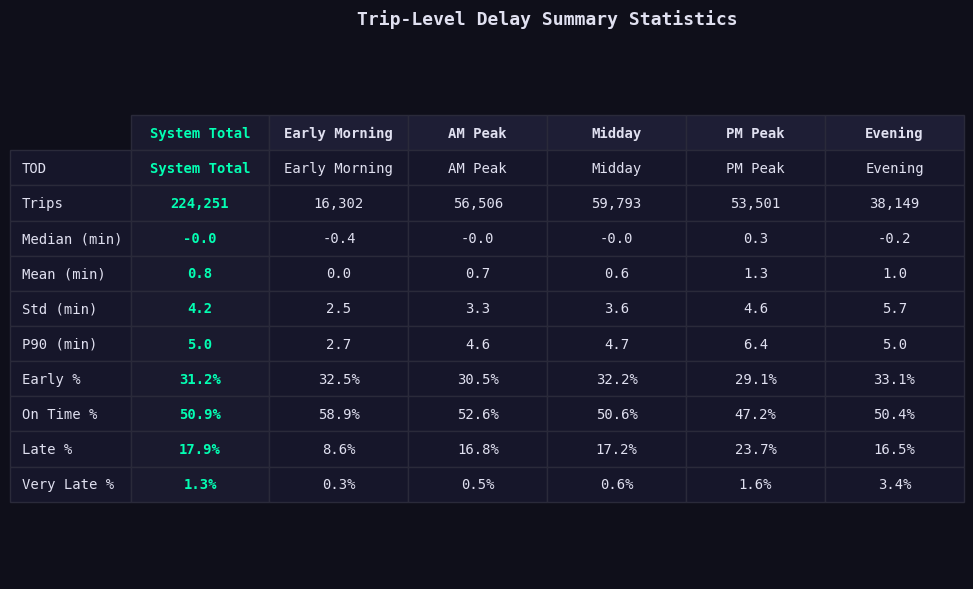

✓ Transposed summary stats table saved


In [ ]:
# Plotting the system-wide and per-TOD delay summary statistics as a transposed table

import matplotlib.gridspec as gridspec

# Building the system-total summary row
overall_row = {
    'TOD':           'System Total',
    'Trips':         f"{len(trips):,}",
    'Median (min)':  f"{trips['delay_median'].median():.1f}",
    'Mean (min)':    f"{trips['delay_median'].mean():.1f}",
    'Std (min)':     f"{trips['delay_median'].std():.1f}",
    'P90 (min)':     f"{trips['delay_median'].quantile(0.9):.1f}",
    'Early %':       f"{trips['is_early'].mean()*100:.1f}%",
    'On Time %':     f"{trips['is_ontime'].mean()*100:.1f}%",
    'Late %':        f"{trips['is_late'].mean()*100:.1f}%",
    'Very Late %':   f"{trips['is_very_late'].mean()*100:.1f}%",
}

# One row per TOD bucket
tod_rows = []
for tod in TOD_ORDER:
    t = trips[trips['tod'] == tod]
    if len(t) == 0:
        continue
    tod_rows.append({
        'TOD':           tod,
        'Trips':         f"{len(t):,}",
        'Median (min)':  f"{t['delay_median'].median():.1f}",
        'Mean (min)':    f"{t['delay_median'].mean():.1f}",
        'Std (min)':     f"{t['delay_median'].std():.1f}",
        'P90 (min)':     f"{t['delay_median'].quantile(0.9):.1f}",
        'Early %':       f"{t['is_early'].mean()*100:.1f}%",
        'On Time %':     f"{t['is_ontime'].mean()*100:.1f}%",
        'Late %':        f"{t['is_late'].mean()*100:.1f}%",
        'Very Late %':   f"{t['is_very_late'].mean()*100:.1f}%",
    })

all_rows = [overall_row] + tod_rows
cols = list(overall_row.keys())

# Original table data
tbl_data = [[r[c] for c in cols] for r in all_rows]

# Transposing so metrics are rows and TOD buckets are columns
row_labels = cols
col_labels = [r['TOD'] for r in all_rows]

tbl_data_t = list(map(list, zip(*tbl_data)))

fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
ax.set_facecolor(PANEL)
ax.axis('off')

tbl = ax.table(
    cellText=tbl_data_t,
    rowLabels=row_labels,
    colLabels=col_labels,
    loc='center',
    cellLoc='center'
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.8)

# Highlighting the system total column and header row
for (row_i, col_i), cell in tbl.get_celld().items():
    cell.set_facecolor(PANEL)
    cell.set_edgecolor('#2a2a3a')
    cell.set_text_props(color=WHITE)

    if row_i == 0:  # column headers
        cell.set_facecolor('#1e1e35')
        cell.set_text_props(color=WHITE, fontweight='bold')

    if col_i == 0:  # system total column
        cell.set_facecolor('#1a1a2e')
        cell.set_text_props(color=GREEN, fontweight='bold')

ax.set_title('Trip-Level Delay Summary Statistics', color=WHITE,
             fontsize=13, fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig('report_1_summary_stats_table_transposed.png', dpi=300,
            bbox_inches='tight', facecolor=BG)
plt.show()

print('\u2713 Transposed summary stats table saved')